## Mapas por Região e Estado de Acidentes

A análise geográfica de acidentes no Brasil permite identificar padrões e concentrações de ocorrências em todo o território nacional. Por meio de mapas organizados por região e estado, gestores públicos conseguem visualizar onde os riscos são mais elevados e direcionar ações de forma mais eficiente.

Os dados utilizados nesses mapas são fornecidos principalmente pela **Polícia Rodoviária Federal (PRF)** e estão disponiveis em [gov.br/prf](https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf). Permiti identificar pontos críticos e orientar investimentos em sinalização, fiscalização e infraestrutura viária.

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import geobr as geobr
import folium

dados = pd.read_csv('datatran2026.csv', encoding='latin-1', sep=';', decimal=',')
display(dados)

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,742921,2026-01-01,quinta-feira,04:04:00,TO,153,155.0,ARAGUAINA,Objeto estático sobre o leito carroçável,Tombamento,...,0,1,3,0,5,-7.291548,-48.286252,SPRF-TO,DEL02-TO,UOP01-DEL02-TO
1,742942,2026-01-01,quinta-feira,06:40:00,MG,262,146.1,RIO CASCA,Condutor Dormindo,Colisão frontal,...,4,1,1,4,3,-20.024073,-42.742229,SPRF-MG,DEL03-MG,UOP03-DEL03-MG
2,742943,2026-01-01,quinta-feira,06:58:00,SC,101,193.0,BIGUACU,Reação tardia ou ineficiente do condutor,Colisão lateral mesmo sentido,...,0,1,2,1,4,-27.489352,-48.655658,SPRF-SC,DEL01-SC,UOP01-DEL01-SC
3,742947,2026-01-01,quinta-feira,07:05:00,DF,60,23.0,BRASILIA,Reação tardia ou ineficiente do condutor,Colisão traseira,...,0,1,1,1,3,-15.988927,-48.226300,SPRF-DF,DEL03-DF,UOP01-DEL03-DF
4,742960,2026-01-01,quinta-feira,06:17:00,MT,163,1044.0,MATUPA,Transitar na contramão,Colisão frontal,...,1,1,3,1,5,-10.143306,-54.930756,SPRF-MT,DEL06-MT,UOP03-DEL06-MT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11375,759579,2026-02-26,quinta-feira,15:22:00,PE,101,126.3,ESCADA,Ausência de reação do condutor,Colisão traseira,...,0,1,0,1,2,-8.370120,-35.230030,SPRF-PE,DEL01-PE,UOP03-DEL01-PE
11376,759600,2026-02-24,terça-feira,11:30:00,RJ,40,43.0,AREAL,Curva acentuada,Colisão com objeto,...,0,1,0,1,1,-22.268991,-43.110284,SPRF-RJ,DEL05-RJ,UOP02-DEL05-RJ
11377,759616,2026-02-12,quinta-feira,12:10:00,SC,116,72.3,MONTE CASTELO,Acesso irregular,Colisão transversal,...,0,2,0,1,2,-26.489944,-50.232859,SPRF-SC,DEL06-SC,UOP02-DEL06-SC
11378,759756,2026-02-21,sábado,17:00:00,BA,324,622.0,SALVADOR,Manobra de mudança de faixa,Incêndio,...,0,1,0,0,1,-12.930698,-38.472260,SPRF-BA,DEL01-BA,UOP01-DEL01-BA


## Tratamento e limpeza dos dados

* Compreender as principais medidas descritivas, como **média**, **mediana** e medidas de **dispersão** (desvio padrão, variância, amplitude), a fim de identificar o comportamento geral dos dados e possíveis outliers.

* Realizar o tratamento de valores ausentes (*missing values*), incluindo:

  * Remoção de observações com dados faltantes, quando apropriado;
  * Avaliação de estratégias de imputação, caso a exclusão comprometa a análise;
  * Correção ou exclusão de registros inconsistentes, como **IDs inválidos ou não encontrados**.

* Padronizar e converter as unidades das variáveis para formatos consistentes, garantindo a comparabilidade dos dados e evitando erros analíticos decorrentes de escalas distintas.

* Verificar e corrigir inconsistências, como:

  * Valores fora do domínio esperado;
  * Duplicidades;
  * Erros de digitação ou formatação.


In [3]:
dados = dados.dropna(how="all") # Garante que so remova se tivermos na linha todas as colunas vazias, temos as informações vitais
dados = dados.astype({
    'dia_semana':     'category',
    'uf':             'category',
    'tipo_acidente':  'category',
    'causa_acidente': 'category',
    'br':             'category',
    'uso_solo':       'category',
    'classificacao_acidente': 'category',
    'mortos':         'int64',      
    'ilesos':         'int64',
    'feridos_leves':  'int64',
    'feridos_graves': 'int64',
    'mortos':         'int64',
    'ilesos':         'int64',
    'feridos_leves':  'int64',
    'feridos_graves': 'int64'
})
coluna = ['data_inversa', 'dia_semana', 'horario', 'uf','municipio', 'br', 'tipo_acidente','causa_acidente', 'uso_solo', 'classificacao_acidente']
dados['horario'] = pd.to_datetime(dados['horario'], format='%H:%M:%S', errors='coerce').dt.hour
tabela_resumo = dados[coluna].describe(include= 'all');
display(tabela_resumo)

,data_inversa,dia_semana,horario,uf,municipio,br,tipo_acidente,causa_acidente,uso_solo,classificacao_acidente
count,11380,11380,11380.000000,11380,11380,11380.0,11380,11380,11380,11379
unique,59,7,NaN,27,1447,105.0,17,66,2,3
top,2026-02-13,sábado,NaN,MG,BRASILIA,101.0,Colisão traseira,Ausência de reação do condutor,Não,Com Vítimas Feridas
freq,279,1931,NaN,1459,141,2157.0,2144,1779,6714,8885
mean,NaN,NaN,12.827241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.006590,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A base de dados analisada contém 101.124 registros, contemplando variáveis de natureza temporal, espacial e características dos acidentes e dos indivíduos envolvidos.

No que se refere à dimensão temporal, observa-se que a variável **data da ocorrência (`data_inversa`)** apresenta 59 datas distintas, indicando concentração dos registros em um intervalo relativamente curto. A data mais frequente foi 22 de fevereiro de 2026, com 2.566 ocorrências. A variável **dia da semana (`dia_semana`)** mostra distribuição ao longo dos sete dias, com maior incidência no sábado (15216 registros). A variável **horário do acidente (`horario`)** apresenta média de aproximadamente 12,7 horas, mediana de 13 horas e desvio padrão de 6,09 horas, evidenciando predominância de ocorrências no período diurno, especialmente entre 8 e 18 horas.

No aspecto espacial, a variável **unidade federativa (`uf`)** abrange as 27 unidades do país, com destaque para Minas Gerais, que concentra 11.115 registros. A variável **município da ocorrência (`municipio`)** apresenta elevada diversidade, com 1.447 municípios distintos, sendo Brasília o mais frequente. As variáveis **rodovia federal (`br`)** indica a localização dos eventos, com 104 rodovias distintas e a predominância da BR-116 (11.981 ocorrências).

Em relação às características dos acidentes, a variável **indicador de causa principal (`causa_principal`)** possui duas categorias, com predominância da categoria "Sim" (52.681 registros). A variável **causa do acidente (`causa_acidente`)** apresenta 68 categorias, sendo a mais frequente "Reação tardia ou ineficiente do condutor" (12.971 ocorrências), o que sugere forte influência de fatores humanos. A variável **ordem do tipo de acidente (`ordem_tipo_acidente`)** apresenta 14 categorias, com predominância da categoria 1 (46.663 registros), indicando concentração em tipos específicos de ocorrência.

No que diz respeito aos veículos, a variável **tipo de veículo (`tipo_veiculo`)** apresenta 21 categorias, sendo "Automóvel" a mais frequente (32.276 registros). A variável **uso do solo (`uso_solo`)** não apresenta 2 categorias diz respeito a características do local do acidente:, indicando a predominância da Zona Rural com cerca de 57556 ocorrências.

Quanto aos indivíduos envolvidos, a variável **tipo de envolvido (`tipo_envolvido`)** indica predominância de condutores (56.757 registros). A variável **estado físico do envolvido (`estado_fisico`)** mostra que a maior parte dos indivíduos encontra-se ilesa (37.109 registros). A variável **idade (`idade`)** apresenta média de 39,66 anos, mediana de 38 anos com especialmente entre 50 e 28 anos de idade. A variável **sexo do envolvido (`sexo`)** apresenta predominância do sexo masculino (61.298 registros). 

De modo geral, os resultados indicam concentração temporal nos finais de semana, predominância de ocorrências no período diurno, forte influência de fatores humanos nas causas dos acidentes e concentração espacial em determinadas unidades federativas e rodovias.

In [4]:
contagens = (dados
    .groupby('uf', observed=True)
    .agg({
        'mortos': 'sum',      # Soma o total de mortos
        'id': 'nunique'       # Conta quantos IDs únicos (acidentes) existem
    })
    .reset_index()
    .rename(columns={
        'mortos': 'Total_Mortos',
        'id': 'Quantidade_Acidentes'
    })
    .sort_values('Total_Mortos', ascending=False)
)

print("TOP 10 estados com mais mortos e seus respectivos números de acidentes:")
display(contagens.head(10))

print(f"\nTotal de mortos no Brasil (2026): {contagens['Total_Mortos'].sum()}")
print(f"Total de acidentes registrados no Brasil (2026): {contagens['Quantidade_Acidentes'].sum()}")

TOP 10 estados com mais mortos e seus respectivos números de acidentes:


,uf,Total_Mortos,Quantidade_Acidentes
10,MG,120,1459
17,PR,101,1193
4,BA,76,669
23,SC,63,1379
18,RJ,61,1007
15,PE,57,545
8,GO,53,527
22,RS,50,686
12,MT,39,451
9,MA,38,205



Total de mortos no Brasil (2026): 939
Total de acidentes registrados no Brasil (2026): 11380


In [5]:
# Baixa o GeoDataFrame com os estados do Brasil e DF
br_uf = geobr.read_state()  
br_uf_d = br_uf.merge(contagens, 
                     left_on='abbrev_state',    
                     right_on='uf', 
                     how='left')
br_uf_d = br_uf_d[["geometry", "Total_Mortos", "abbrev_state"]]  

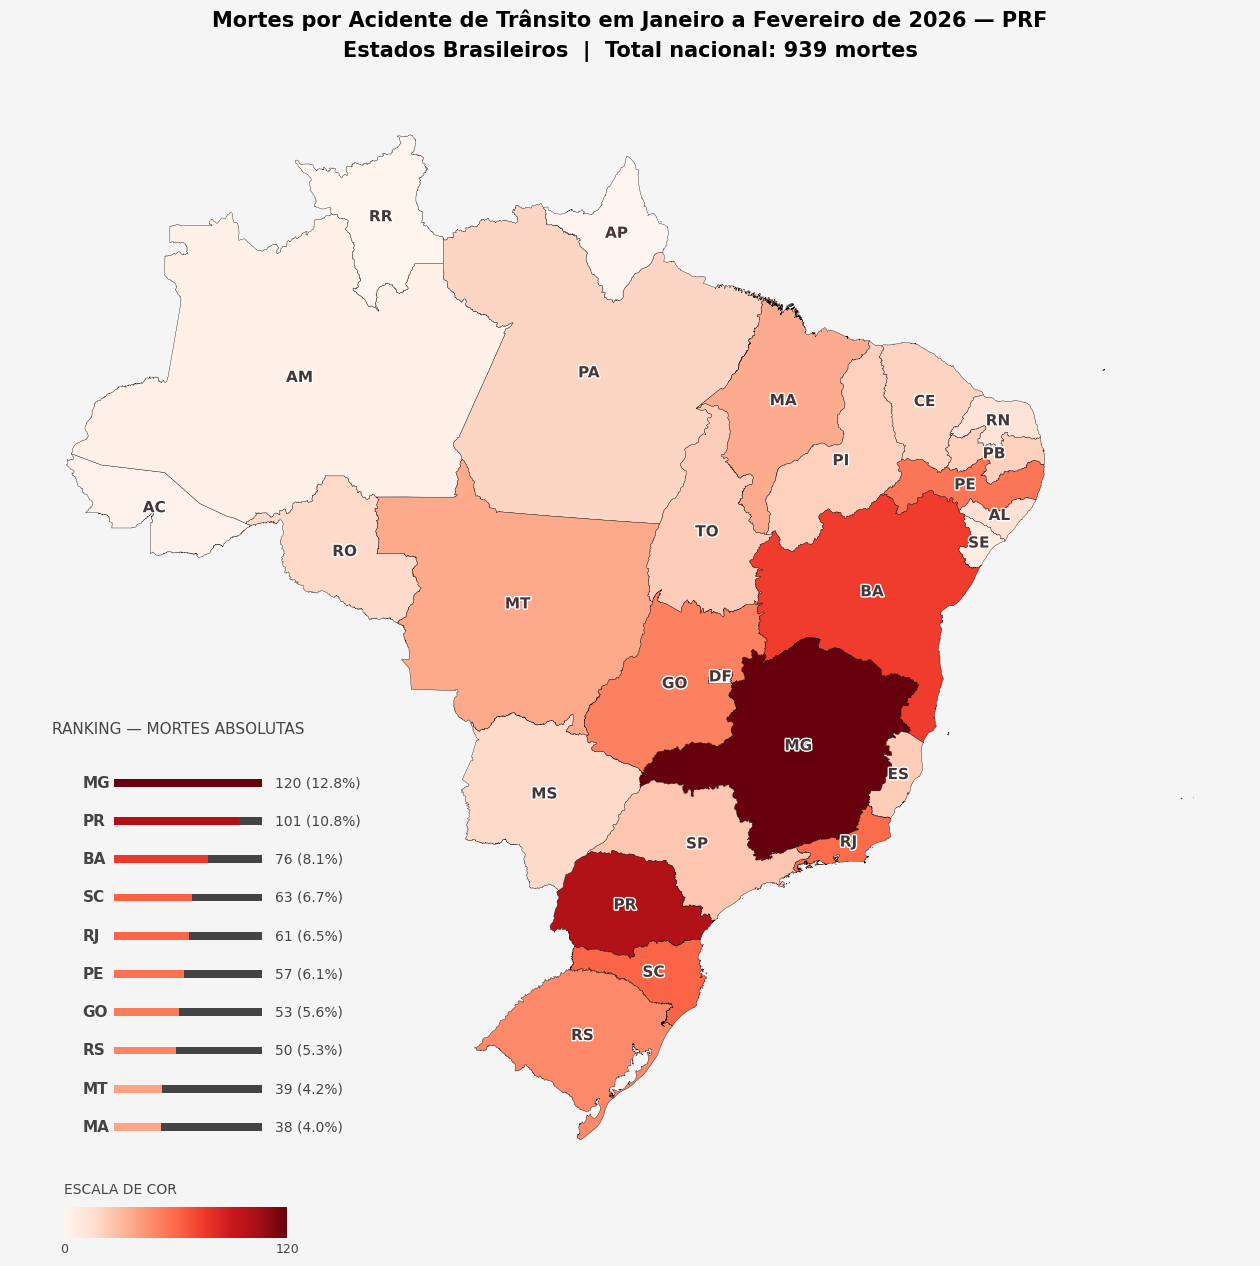

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import FancyArrowPatch

# =============================================================================
# MAPA COROPLÉTICO — Mortes por Acidente de Trânsito (PRF, Janeiro-fevereiro 2026)
# =============================================================================

f, ax = plt.subplots()
f.set_size_inches(16, 16)
f.patch.set_facecolor("#F5F5F5")

# --- 2. MAPA COROPLÉTICO ------------------------------------------------------
br_uf_d.plot(
    ax=ax,
    column="Total_Mortos",
    cmap="Reds", 
    edgecolor="black",
    linewidth=0.25,
    legend=False,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'}
)

# --- 3. SIGLAS DOS ESTADOS ----------------------------------------------------
import matplotlib.patheffects as path_effects
for idx, row in br_uf_d.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    sigla = row.get("SIGLA_UF") or row.get("abbrev_state") or row.get("UF", "")
    efeito_borda = [path_effects.withStroke(linewidth=2, foreground="white")]
    ax.annotate(text=sigla, xy=(x, y), ha='center', va='center', 
                fontsize=11, fontweight='bold', color="#463636", zorder=5, path_effects=efeito_borda)

# --- 4. TÍTULO PRINCIPAL E SUBTÍTULO ------------------------------------------
total_mortes = int(br_uf_d["Total_Mortos"].sum())
ax.set_title(
    "Mortes por Acidente de Trânsito em Janeiro a Fevereiro de 2026 — PRF\n"
    f"Estados Brasileiros  |  Total nacional: {total_mortes:,} mortes".replace(",", "."),
    fontsize=15, fontweight='bold', pad=20, linespacing=1.6
)
ax.set_axis_off()

# --- 5.5 RANKING E ESCALA DE CORES (ESTILO INFOGRÁFICO) ------------------------
# Criando um eixo dedicado para o conjunto ranking + escala
ax_ranking = inset_axes(ax, width="20%", height="35%", loc='lower left', borderpad=3)
#ax_ranking.set_facecolor("#1a1a1a") # Fundo escuro conforme a imagem enviada
#f.set_facecolor("#3D3B3B")          # Ajustando o fundo da figura para combinar

# Dados do Top 10
top10 = br_uf_d.nlargest(10, 'Total_Mortos').sort_values('Total_Mortos', ascending=True)
y_pos = range(len(top10))

# 1. Desenhar as barras finas (estilo progresso)
# Fundo da barra (cinza escuro)
ax_ranking.barh(y_pos, [top10['Total_Mortos'].max()]*10, color="#444444", height=0.2)
# Barra de progresso (gradiente Reds)
colors = [plt.cm.Reds(val/top10['Total_Mortos'].max()) for val in top10['Total_Mortos']]
ax_ranking.barh(y_pos, top10['Total_Mortos'], color=colors, height=0.2)

# 2. Adicionar Textos (Ranking, Sigla e Valor)
for i, (idx, row) in enumerate(top10.iterrows()):
    # Posição (ex: 1, 2, 3...)
    #ax_ranking.text(-40, i, f"{100-i}", color='#888888', va='center', fontsize=10)
    # Sigla do Estado
    ax_ranking.text(-25, i, row['abbrev_state'], color="#444444", va='center', fontweight='bold', fontsize=11)
    # Valor Absoluto
    # Uma única linha que junta o valor e o percentual
    ax_ranking.text(top10['Total_Mortos'].max() + 10, i, f"{int(row['Total_Mortos'])} ({ (row['Total_Mortos']/total_mortes)*100:.1f}%)", color="#444444", va='center', fontsize=10)

# 3. Escala de Cor (Gradiente Inferior)
# Criar um pequeno eixo dentro do eixo de ranking para o gradiente
ax_gradient = inset_axes(ax_ranking, width="90%", height="8%", loc='lower center', bbox_to_anchor=(0, -0.25, 1, 1), bbox_transform=ax_ranking.transAxes)

import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=top10['Total_Mortos'].max())
cb_grad = mpl.colorbar.ColorbarBase(ax_gradient, cmap=plt.cm.Reds, norm=norm, orientation='horizontal')
cb_grad.outline.set_visible(False)
ax_gradient.set_title("ESCALA DE COR", color= "#444444", fontsize=10, loc='left', pad=10)
ax_gradient.set_xticks([0, top10['Total_Mortos'].max()])
ax_gradient.set_xticklabels(['0', f"{int(top10['Total_Mortos'].max())}"], color="#444444", fontsize=9)
ax_gradient.tick_params(size=0)
ax_ranking.set_xticks([]) # Remove valores do eixo X para limpar o visual

# Limpeza estética do ranking
ax_ranking.set_title("RANKING — MORTES ABSOLUTAS", color="#444444", fontsize=11, pad=20, loc='left')
ax_ranking.set_xlim(-50, top10['Total_Mortos'].max() + 30)
ax_ranking.axis('off')
plt.show()

O mapa evidencia a distribuição espacial das mortes por acidentes de trânsito no Brasil, apresentando padrão semelhante ao observado para os feridos graves. Há forte concentração de óbitos nas regiões Sudeste e Sul, com destaque para Minas Gerais e Paraná, que apresentam os maiores valores absolutos.

As regiões Norte e parte do Nordeste registram menores números de mortes, enquanto o Centro-Oeste apresenta níveis intermediários. Esse padrão reforça a influência de fatores como volume de tráfego, densidade populacional e extensão da malha rodoviária, mais intensos nas regiões mais desenvolvidas.

De forma geral, a distribuição sugere que o número de óbitos está mais associado à exposição ao tráfego do que necessariamente ao risco individual. Assim, estados com maior circulação de veículos tendem a concentrar mais mortes.

Em síntese, observa-se uma clara concentração regional dos óbitos nas áreas com maior fluxo rodoviário, indicando a necessidade de análises complementares baseadas em taxas para avaliar de forma mais precisa o risco relativo entre os estados.


In [7]:
contagens = (dados
    .groupby('uf', observed=True)
    .agg({
        'feridos_graves': 'sum',      # Soma o total de feridos graves
        'id': 'nunique'       # Conta quantos IDs únicos (acidentes) existem
    })
    .reset_index()
    .rename(columns={
        'feridos_graves': 'Total_Feridos_Graves',
        'id': 'Quantidade_Acidentes'
    })
    .sort_values('Total_Feridos_Graves', ascending=False)
)

print("TOP 10 estados com mais feridos graves e seus respectivos números de acidentes:")
display(contagens.head(10))

print(f"\nTotal de feridos graves no Brasil (2026): {contagens['Total_Feridos_Graves'].sum()}")
print(f"Total de acidentes registrados no Brasil (2026): {contagens['Quantidade_Acidentes'].sum()}")

TOP 10 estados com mais feridos graves e seus respectivos números de acidentes:


,uf,Total_Feridos_Graves,Quantidade_Acidentes
10,MG,436,1459
23,SC,364,1379
17,PR,315,1193
4,BA,260,669
18,RJ,207,1007
15,PE,194,545
22,RS,161,686
8,GO,157,527
25,SP,142,682
14,PB,127,306



Total de feridos graves no Brasil (2026): 3264
Total de acidentes registrados no Brasil (2026): 11380


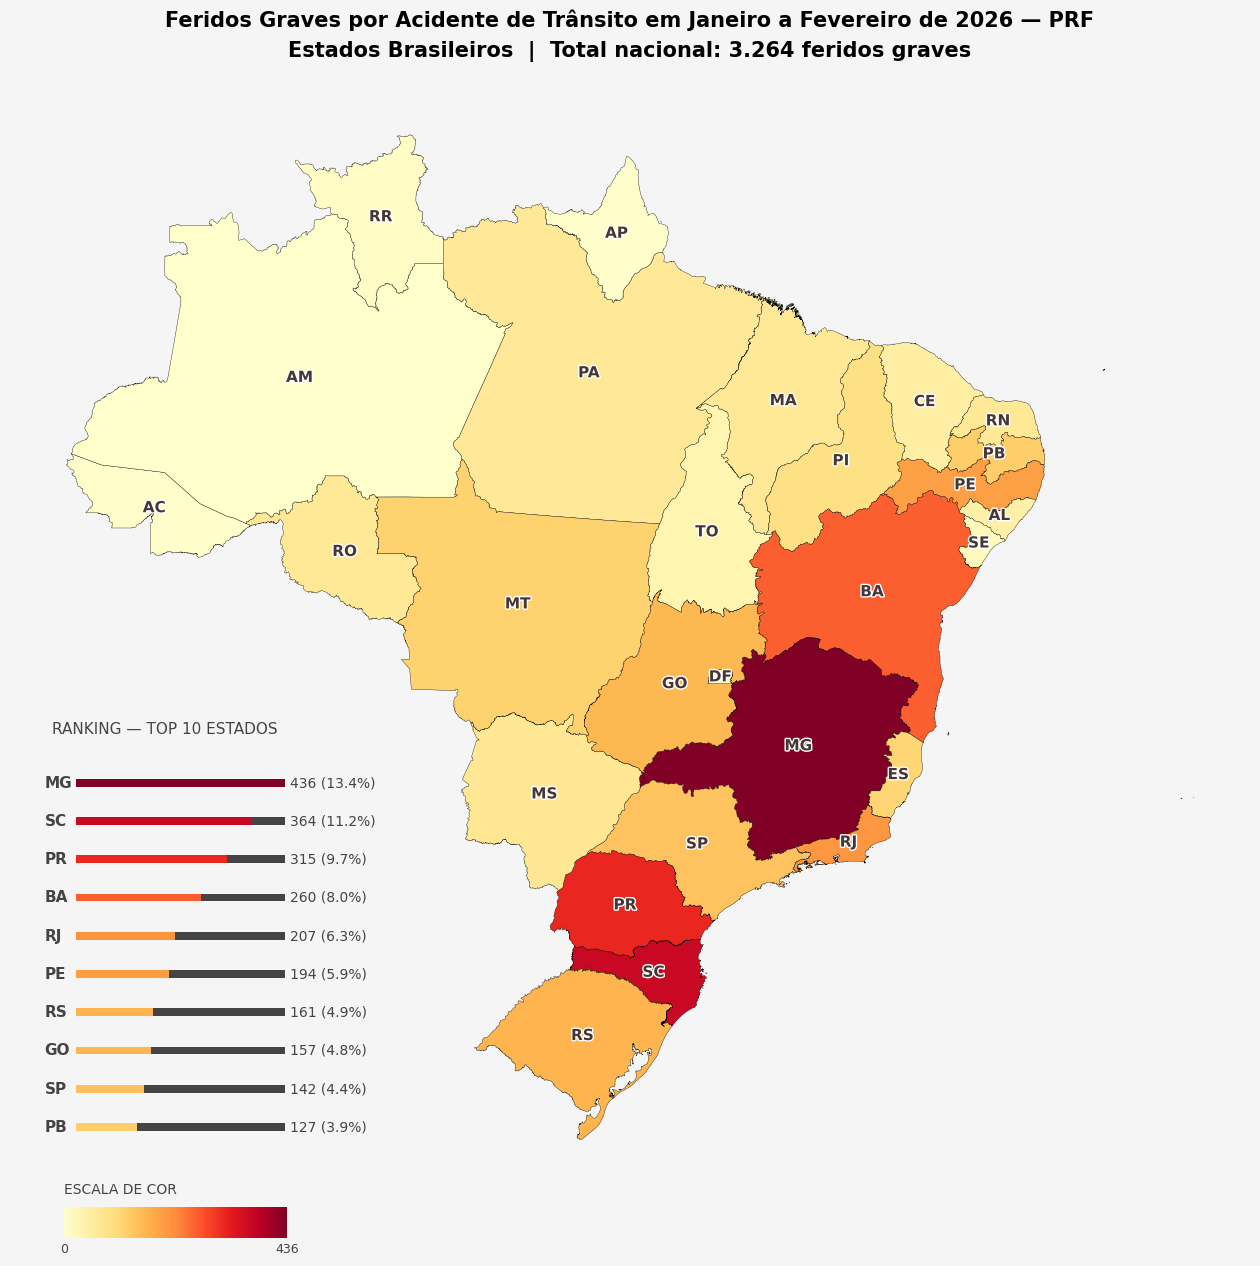

In [8]:
br_uf_d = br_uf.merge(contagens, 
                     left_on='abbrev_state',    
                     right_on='uf', 
                     how='left')
br_uf_d = br_uf_d[["geometry", "Total_Feridos_Graves", "abbrev_state"]]

# =============================================================================
# MAPA COROPLÉTICO — Total de Feridos graves por Acidente de Trânsito (PRF, Janeiro-fevereiro 2026)
# =============================================================================

f, ax = plt.subplots()
f.set_size_inches(16, 16)
f.patch.set_facecolor("#F5F5F5")

# --- 2. MAPA COROPLÉTICO ------------------------------------------------------
br_uf_d.plot(
    ax=ax,
    column="Total_Feridos_Graves",
    cmap="YlOrRd", 
    edgecolor="black",
    linewidth=0.25,
    legend=False,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'}
)

# --- 3. SIGLAS DOS ESTADOS ----------------------------------------------------
for idx, row in br_uf_d.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    sigla = row.get("SIGLA_UF") or row.get("abbrev_state") or row.get("UF", "")
    efeito_borda = [path_effects.withStroke(linewidth=2, foreground="white")]
    ax.annotate(text=sigla, xy=(x, y), ha='center', va='center', 
                fontsize=11, fontweight='bold', color="#463636", zorder=5, path_effects=efeito_borda)
    
# --- 4. TÍTULO PRINCIPAL E SUBTÍTULO ------------------------------------------
total_feridos_graves = int(br_uf_d["Total_Feridos_Graves"].sum())
ax.set_title(
    "Feridos Graves por Acidente de Trânsito em Janeiro a Fevereiro de 2026 — PRF\n"
    f"Estados Brasileiros  |  Total nacional: {total_feridos_graves:,} feridos graves".replace(",", "."),
    fontsize=15, fontweight='bold', pad=20, linespacing=1.6
)
ax.set_axis_off()

# --- 5.5 RANKING E ESCALA DE CORES (ESTILO INFOGRÁFICO) ------------------------
# Criando um eixo dedicado para o conjunto ranking + escala
ax_ranking = inset_axes(ax, width="20%", height="35%", loc='lower left', borderpad=3)
#ax_ranking.set_facecolor("#1a1a1a") # Fundo escuro conforme a imagem enviada
#f.set_facecolor("#3D3B3B")          # Ajustando o fundo da figura para combinar

# Dados do Top 10
top10 = br_uf_d.nlargest(10, 'Total_Feridos_Graves').sort_values('Total_Feridos_Graves', ascending=True)
y_pos = range(len(top10))

# 1. Desenhar as barras finas (estilo progresso)
# Fundo da barra (cinza escuro)
ax_ranking.barh(y_pos, [top10['Total_Feridos_Graves'].max()]*10, color="#444444", height=0.2)
# Barra de progresso (gradiente Reds)
colors = [plt.cm.YlOrRd(val/top10['Total_Feridos_Graves'].max()) for val in top10['Total_Feridos_Graves']]
ax_ranking.barh(y_pos, top10['Total_Feridos_Graves'], color=colors, height=0.2)

# 2. Adicionar Textos (Ranking, Sigla e Valor)
for i, (idx, row) in enumerate(top10.iterrows()):
    # Posição (ex: 1, 2, 3...)
    #ax_ranking.text(-40, i, f"{100-i}", color='#888888', va='center', fontsize=10)
    # Sigla do Estado
    ax_ranking.text(-65, i, row['abbrev_state'], color="#444444", va='center', fontweight='bold', fontsize=11)
    # Valor Absoluto
    # Uma única linha que junta o valor e o percentual
    ax_ranking.text(top10['Total_Feridos_Graves'].max() + 10, i, f"{int(row['Total_Feridos_Graves'])} ({ (row['Total_Feridos_Graves']/total_feridos_graves)*100:.1f}%)", color="#444444", va='center', fontsize=10)

# 3. Escala de Cor (Gradiente Inferior)
# Criar um pequeno eixo dentro do eixo de ranking para o gradiente
ax_gradient = inset_axes(ax_ranking, width="90%", height="8%", loc='lower center', bbox_to_anchor=(0, -0.25, 1, 1), bbox_transform=ax_ranking.transAxes)

import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=top10['Total_Feridos_Graves'].max())
cb_grad = mpl.colorbar.ColorbarBase(ax_gradient, cmap=plt.cm.YlOrRd, norm=norm, orientation='horizontal')
cb_grad.outline.set_visible(False)
ax_gradient.set_title("ESCALA DE COR", color= "#444444", fontsize=10, loc='left', pad=10)
ax_gradient.set_xticks([0, top10['Total_Feridos_Graves'].max()])
ax_gradient.set_xticklabels(['0', f"{int(top10['Total_Feridos_Graves'].max())}"], color="#444444", fontsize=9)
ax_gradient.tick_params(size=0)
ax_ranking.set_xticks([]) # Remove valores do eixo X para limpar o visual

# Limpeza estética do ranking
ax_ranking.set_title("RANKING — TOP 10 ESTADOS", color="#444444", fontsize=11, pad=20, loc='left')
ax_ranking.set_xlim(-50, top10['Total_Feridos_Graves'].max() + 30)
ax_ranking.axis('off')
plt.show()

O mapa apresenta a distribuição espacial do número de feridos graves em acidentes de trânsito no Brasil, evidenciando forte concentração nas regiões Sudeste e Sul. Destaca-se especialmente o estado de Minas Gerais, com o maior volume absoluto, seguido por estados como São Paulo, Paraná e Rio Grande do Sul.

Nas regiões Norte e parte do Nordeste, observa-se menor intensidade, indicando menor número absoluto de ocorrências. Já o Centro-Oeste apresenta valores intermediários, sem grandes destaques em relação ao restante do país.

Esse padrão sugere que o número de feridos graves está fortemente associado a fatores como maior densidade populacional, volume de tráfego e extensão da malha rodoviária, mais intensos nas regiões mais desenvolvidas do país. Portanto, não necessariamente indica maior risco relativo, mas sim maior exposição ao tráfego.

Em síntese, há uma clara concentração espacial dos casos nas regiões com maior fluxo de veículos, reforçando a necessidade de análises complementares que considerem taxas (por população ou frota) para uma avaliação mais precisa do risco.


In [9]:
contagens = (dados
    .groupby('uf', observed=True)
    .agg({
        'ignorados': 'sum',      # Soma o total de feridos graves
        'id': 'nunique'       # Conta quantos IDs únicos (acidentes) existem
    })
    .reset_index()
    .rename(columns={
        'ignorados': 'Total_casos_ignorados',
        'id': 'Quantidade_Acidentes'
    })
    .sort_values('Total_casos_ignorados', ascending=False)
)

print("TOP 10 estados com mais casos ignorados e seus respectivos números de acidentes:")
display(contagens[['uf', 'Total_casos_ignorados']].head(10))
print(f"\nTotal de casos ignorados no Brasil (2026): {contagens['Total_casos_ignorados'].sum()}")


TOP 10 estados com mais casos ignorados e seus respectivos números de acidentes:


,uf,Total_casos_ignorados
10,MG,569
17,PR,524
12,MT,396
23,SC,347
4,BA,285
8,GO,230
25,SP,220
18,RJ,207
22,RS,189
15,PE,174



Total de casos ignorados no Brasil (2026): 4281


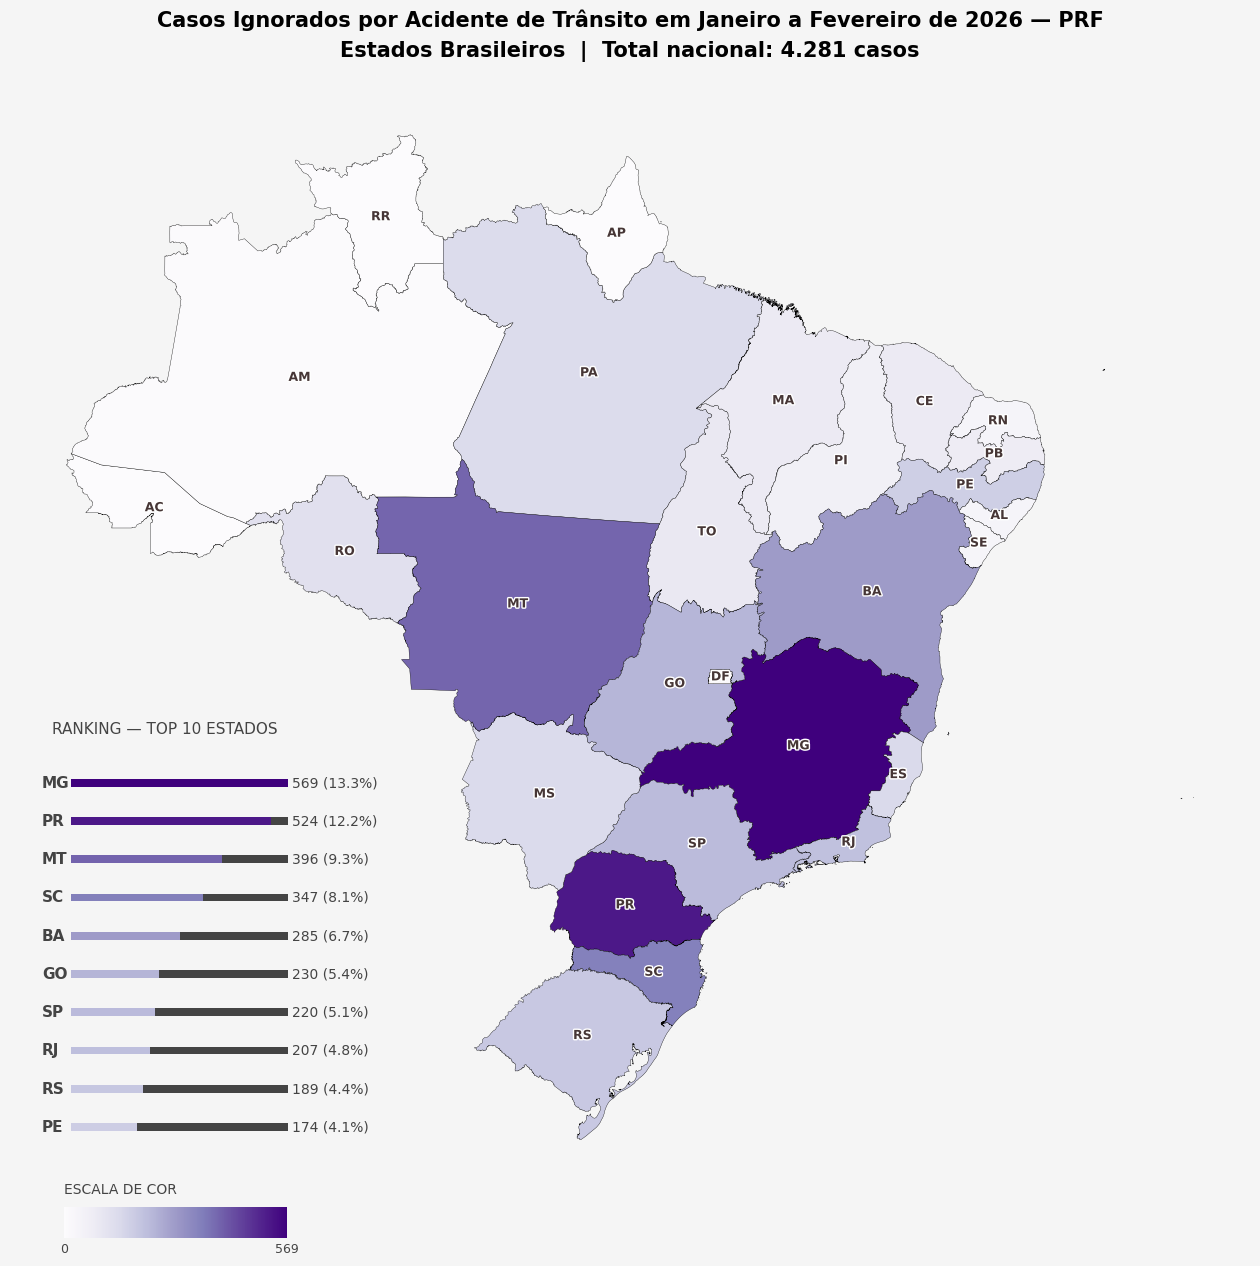

In [10]:
br_uf_d = br_uf.merge(contagens, 
                     left_on='abbrev_state',    
                     right_on='uf', 
                     how='left')
br_uf_d = br_uf_d[["geometry", "Total_casos_ignorados", "abbrev_state"]]

# =============================================================================
# MAPA COROPLÉTICO — Total de Feridos graves por Acidente de Trânsito (PRF, Janeiro-fevereiro 2026)
# =============================================================================

f, ax = plt.subplots()
f.set_size_inches(16, 16)
f.patch.set_facecolor("#F5F5F5")

# --- 2. MAPA COROPLÉTICO ------------------------------------------------------
br_uf_d.plot(
    ax=ax,
    column="Total_casos_ignorados",
    cmap="Purples", 
    edgecolor="black",
    linewidth=0.25,
    legend=False,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'}
)

# --- 3. SIGLAS DOS ESTADOS ----------------------------------------------------
for idx, row in br_uf_d.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    sigla = row.get("SIGLA_UF") or row.get("abbrev_state") or row.get("UF", "")
    efeito_borda = [path_effects.withStroke(linewidth=2, foreground="white")]
    ax.annotate(text=sigla, xy=(x, y), ha='center', va='center', 
                fontsize=9, fontweight='bold', color="#463636", zorder=5, path_effects=efeito_borda)

# --- 4. TÍTULO PRINCIPAL E SUBTÍTULO ------------------------------------------
total_casos_ignorados = int(br_uf_d["Total_casos_ignorados"].sum())
ax.set_title(
    "Casos Ignorados por Acidente de Trânsito em Janeiro a Fevereiro de 2026 — PRF\n"
    f"Estados Brasileiros  |  Total nacional: {total_casos_ignorados:,} casos".replace(",", "."),
    fontsize=15, fontweight='bold', pad=20, linespacing=1.6
)
ax.set_axis_off()

# --- 5.5 RANKING E ESCALA DE CORES (ESTILO INFOGRÁFICO) ------------------------
# Criando um eixo dedicado para o conjunto ranking + escala
ax_ranking = inset_axes(ax, width="20%", height="35%", loc='lower left', borderpad=3)
#ax_ranking.set_facecolor("#1a1a1a") # Fundo escuro conforme a imagem enviada
#f.set_facecolor("#3D3B3B")          # Ajustando o fundo da figura para combinar

# Dados do Top 10
top10 = br_uf_d.nlargest(10, 'Total_casos_ignorados').sort_values('Total_casos_ignorados', ascending=True)
y_pos = range(len(top10))

# 1. Desenhar as barras finas (estilo progresso)
# Fundo da barra (cinza escuro)
ax_ranking.barh(y_pos, [top10['Total_casos_ignorados'].max()]*10, color="#444444", height=0.2)
# Barra de progresso (gradiente Reds)
colors = [plt.cm.Purples(val/top10['Total_casos_ignorados'].max()) for val in top10['Total_casos_ignorados']]
ax_ranking.barh(y_pos, top10['Total_casos_ignorados'], color=colors, height=0.2)

# 2. Adicionar Textos (Ranking, Sigla e Valor)
for i, (idx, row) in enumerate(top10.iterrows()):
    # Posição (ex: 1, 2, 3...)
    #ax_ranking.text(-40, i, f"{100-i}", color='#888888', va='center', fontsize=10)
    # Sigla do Estado
    ax_ranking.text(-75, i, row['abbrev_state'], color="#444444", va='center', fontweight='bold', fontsize=11)
    # Valor Absoluto
    # Uma única linha que junta o valor e o percentual
    ax_ranking.text(top10['Total_casos_ignorados'].max() + 10, i, f"{int(row['Total_casos_ignorados'])} ({ (row['Total_casos_ignorados']/total_casos_ignorados)*100:.1f}%)", color="#444444", va='center', fontsize=10)

# 3. Escala de Cor (Gradiente Inferior)
# Criar um pequeno eixo dentro do eixo de ranking para o gradiente
ax_gradient = inset_axes(ax_ranking, width="90%", height="8%", loc='lower center', bbox_to_anchor=(0, -0.25, 1, 1), bbox_transform=ax_ranking.transAxes)

import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=top10['Total_casos_ignorados'].max())
cb_grad = mpl.colorbar.ColorbarBase(ax_gradient, cmap=plt.cm.Purples, norm=norm, orientation='horizontal')
cb_grad.outline.set_visible(False)
ax_gradient.set_title("ESCALA DE COR", color= "#444444", fontsize=10, loc='left', pad=10)
ax_gradient.set_xticks([0, top10['Total_casos_ignorados'].max()])
ax_gradient.set_xticklabels(['0', f"{int(top10['Total_casos_ignorados'].max())}"], color="#444444", fontsize=9)
ax_gradient.tick_params(size=0)
ax_ranking.set_xticks([]) # Remove valores do eixo X para limpar o visual

# Limpeza estética do ranking
ax_ranking.set_title("RANKING — TOP 10 ESTADOS", color="#444444", fontsize=11, pad=20, loc='left')
ax_ranking.set_xlim(-50, top10['Total_casos_ignorados'].max() + 30)
ax_ranking.axis('off')
plt.show()

Total de pessoas envolvidas na ocorrência cuja condição física não foi informada: observa-se que o estado de Minas Gerais lidera os registros, com 569 casos, correspondendo a aproximadamente 13% do total. Destaca-se também o estado do Mato Grosso, com cerca de 9%. Esse volume é relevante e pode refletir um cenário em que parte das pessoas envolvidas não teve sua condição física devidamente classificada (feridos graves, leves ou ilesos), o que pode indicar subnotificação ou inconsistências no registro dos dados, especialmente no Mato Grosso.


### Mapa do brasil para verificar o horário médio dos acidentes no brasil

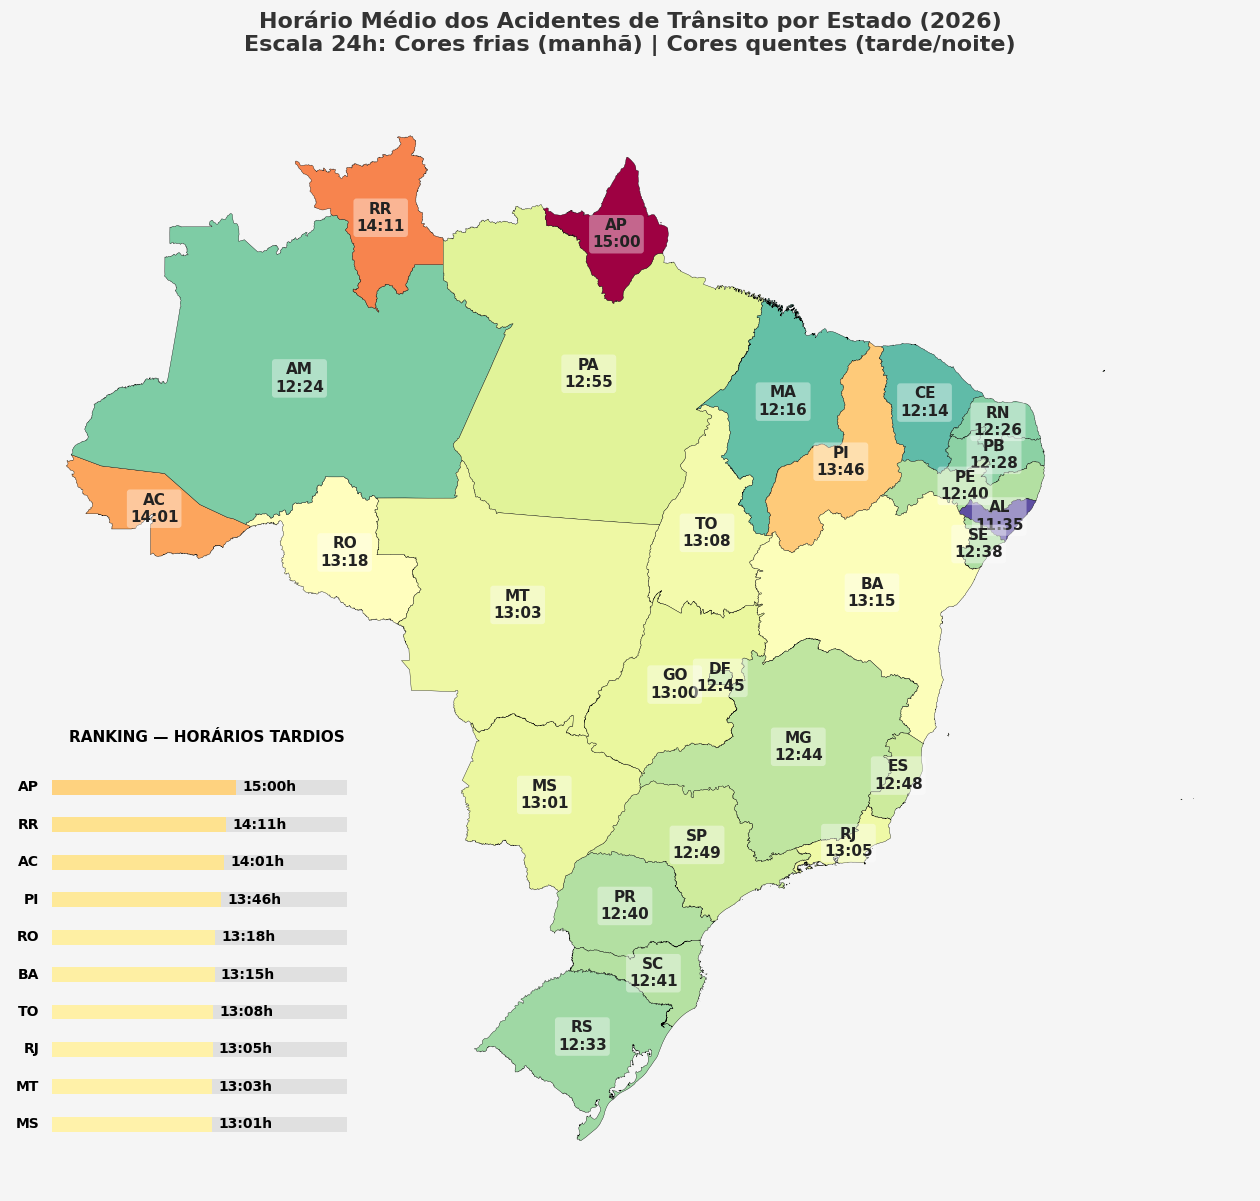

In [11]:
horario_medio_por_uf = (dados
    .groupby('uf', observed=True)
    .agg({
        'horario': 'mean',  # Calcula a média aritmética dos horários
        'id': 'nunique'     # Conta o total de acidentes para referência
    })
    .reset_index()
    .rename(columns={'horario': 'Hora_Media'})
)

# Função simples para transformar 14.5 em "14:30" apenas para o texto do ranking
def formatar_hora_simples(decimal):
    h = int(decimal)
    m = int((decimal - h) * 60)
    return f"{h:02d}:{m:02d}"

horario_medio_por_uf['Hora_Label'] = horario_medio_por_uf['Hora_Media'].apply(formatar_hora_simples)

# Unindo com o mapa do geobr (br_uf)
br_uf_d = br_uf.merge(horario_medio_por_uf, left_on='abbrev_state', right_on='uf', how='left')

# 1. Escolha da nova escala (Spectral_r para azul ser manhã e vermelho ser noite)
nova_cmap = "Spectral_r" 
f, ax = plt.subplots(figsize=(16, 16))
f.patch.set_facecolor("#F5F5F5")

# --- 2. MAPA COROPLÉTICO ---
br_uf_d.plot(
    ax=ax,
    column="Hora_Media",
    cmap=nova_cmap, 
    edgecolor="black",
    linewidth=0.25,
    missing_kwds={'color': 'lightgrey'}
)

# --- 3. TEXTOS DENTRO DOS ESTADOS (Sigla + Hora) ---
for idx, row in br_uf_d.iterrows():
    if pd.notna(row['Hora_Media']): # Só escreve se houver dados
        centro = row.geometry.centroid
        # Criamos o texto com a sigla e o horário embaixo
        texto_estado = f"{row['abbrev_state']}\n{row['Hora_Label']}"
        ax.annotate(
            text=texto_estado, 
            xy=(centro.x, centro.y), 
            ha='center', va='center', 
            fontsize=11,        # Tamanho pequeno para não poluir
            fontweight='bold', 
            color="#222222", 
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.4, ec='none') # Fundo sutil para legibilidade
        )

# --- 4. RANKING LATERAL ---
ax_ranking = inset_axes(ax, width="25%", height="35%", loc='lower left', borderpad=3)

top10 = br_uf_d.nlargest(10, 'Hora_Media').sort_values('Hora_Media', ascending=True)
y_pos = range(len(top10))

# Barras de fundo e progresso
ax_ranking.barh(y_pos, [24]*10, color="#E0E0E0", height=0.4) 
# Aplicando a mesma nova escala nas barras
# Forma moderna de acessar o colormap
colors = [plt.colormaps[nova_cmap](val/24) for val in top10['Hora_Media']]
ax_ranking.barh(y_pos, top10['Hora_Media'], color=colors, height=0.4)

# Legendas do Ranking
for i, (idx, row) in enumerate(top10.iterrows()):
    ax_ranking.text(-1, i, row['abbrev_state'], ha='right', va='center', fontweight='bold', fontsize=10)
    ax_ranking.text(row['Hora_Media'] + 0.5, i, f"{row['Hora_Label']}h", va='center', fontweight='bold', fontsize=10)

# --- 5. TÍTULO E FINALIZAÇÃO ---
ax.set_title("Horário Médio dos Acidentes de Trânsito por Estado (2026)\n"
             "Escala 24h: Cores frias (manhã) | Cores quentes (tarde/noite)", 
             fontsize=16, fontweight='bold', pad=25, color="#333333")

ax_ranking.set_title("RANKING — HORÁRIOS TARDIOS", fontsize=11, fontweight='bold', pad=15)
ax_ranking.axis('off')
ax.set_axis_off()

plt.show()


O mapa revela que a periculosidade nas rodovias federais brasileiras não é estática, mas sim um fenômeno que "caminha" pelo relógio dependendo da região. Enquanto o **Centro-Sul e Sudeste** apresentam uma estabilidade notável com acidentes concentrados entre **12:30 e 13:00**, sugerindo uma forte ligação com o fluxo comercial e o cansaço pós-almoço, o **Norte e o Piauí** deslocam esse risco para o meio da tarde, com o **Amapá atingindo o pico às 15:00**.

Essa variação indica que estados mais remotos ou com logística de longa distância (como AP, RR e AC) enfrentam riscos mais tardios, possivelmente pelo acúmulo de horas de direção. Por outro lado, o caso isolado de **Alagoas**, com a média mais precoce do país (**11:35**), aponta para uma dinâmica de tráfego matinal única. Em suma, o gráfico prova que o planejamento de segurança viária no Brasil não pode ser uniforme: a "hora do perigo" muda conforme a latitude e a característica econômica de cada estado.

### Selecionando o estado com maior numero de mortos

(np.float64(-10.0),
 np.float64(13.0),
 np.float64(-0.67),
 np.float64(9.670000000000002))

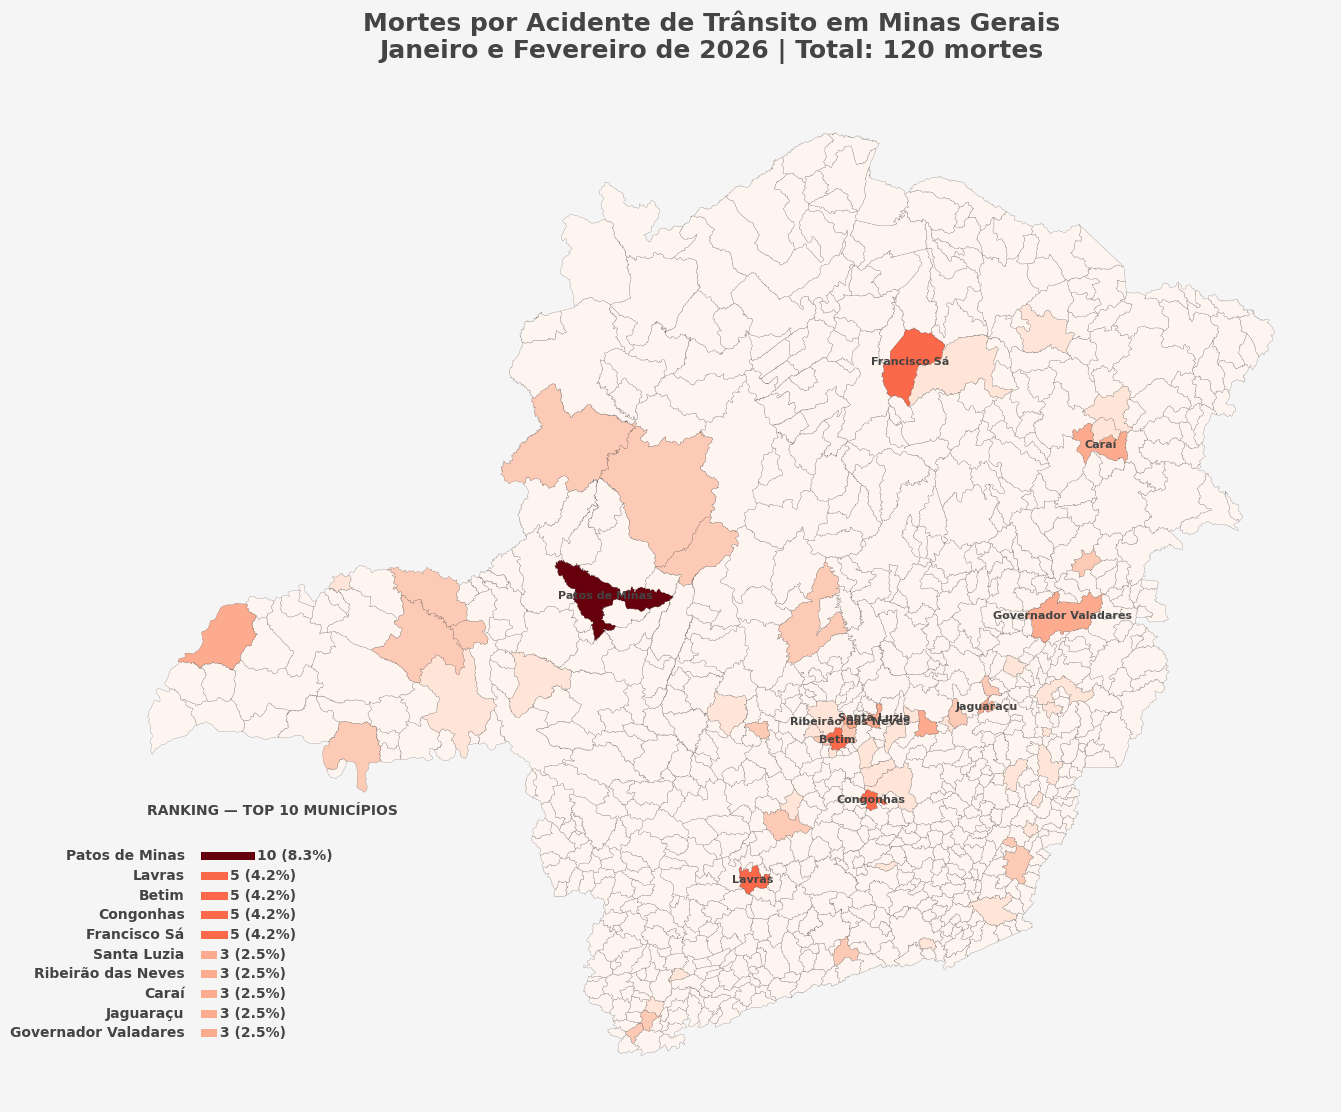

In [12]:
import unicodedata
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- 1. FUNÇÃO DE LIMPEZA DE NOMES ---
def limpar_nomes(coluna):
    return (coluna
            .astype(str)
            .str.strip()
            .str.lower()
            .str.normalize('NFKD')
            .str.encode('ascii', errors='ignore')
            .str.decode('utf-8')
            .str.replace(r'\s+', ' ', regex=True))

# --- 2. PREPARAÇÃO DOS DADOS DA PRF ---
dados['municipio_limpo'] = limpar_nomes(dados['municipio'])
contagens_mg = (dados[dados['uf'] == 'MG']
    .groupby('municipio_limpo', observed=True)
    .agg(
        Total_Mortos=('mortos', 'sum'),
        Quantidade_Acidentes=('id', 'nunique')
    )
    .reset_index()
)

# --- 3. CARREGANDO E LIMPANDO O MAPA (geobr) ---
mapa_mg = geobr.read_municipality(code_muni="MG", year=2022)
mapa_mg['name_muni_limpo'] = limpar_nomes(mapa_mg['name_muni'])

# --- 4. O MERGE (UNIÃO) ---
mg_mapa = mapa_mg.merge(
    contagens_mg, 
    left_on='name_muni_limpo', 
    right_on='municipio_limpo', 
    how='left'
)
mg_mapa['Total_Mortos'] = mg_mapa['Total_Mortos'].fillna(0)

# --- 5. CONFIGURAÇÃO DO GRÁFICO ---
f, ax = plt.subplots(figsize=(16, 16))
f.patch.set_facecolor("#F5F5F5")

# Plot do Mapa
mg_mapa.plot(
    ax=ax,
    column="Total_Mortos",
    cmap="Reds", 
    edgecolor="black",
    linewidth=0.1,
    legend=False,
    missing_kwds={'color': 'lightgrey'}
)

# --- 6. ANOTAÇÕES (TOP 10 NOMES NO MAPA) ---
top10_nomes = mg_mapa.nlargest(10, 'Total_Mortos')
for idx, row in top10_nomes.iterrows():
    centro = row.geometry.centroid
    ax.annotate(
        text=row["name_muni"], 
        xy=(centro.x, centro.y), 
        ha='center', va='center', 
        fontsize=8, fontweight='bold', color="#444444"
    )

# --- 7. TÍTULO ---
total_mortes = int(mg_mapa["Total_Mortos"].sum())
ax.set_title(
    "Mortes por Acidente de Trânsito em Minas Gerais\n"
    f"Janeiro e Fevereiro de 2026 | Total: {total_mortes} mortes",
    fontsize=18, fontweight='bold', pad=20, color="#444444"
)
ax.set_axis_off()

# --- 8. RANKING LATERAL (AJUSTE DE POSIÇÃO E TAMANHO) ---
# Aumentei um pouco a largura (width) e a altura (height) para dar respiro
ax_ranking = inset_axes(ax, width="10%", height="20%", loc='lower left', borderpad=4)
top10 = mg_mapa.nlargest(10, 'Total_Mortos').sort_values('Total_Mortos', ascending=True)
y_pos = range(len(top10))

# Ajuste da espessura das barras: height=0.4 (antes era 0.3)
ax_ranking.barh(y_pos, [top10['Total_Mortos'].max()]*10, color="#E0E0E0", height=0)
colors = [plt.cm.Reds(val/top10['Total_Mortos'].max() if top10['Total_Mortos'].max() > 0 else 0) for val in top10['Total_Mortos']]
ax_ranking.barh(y_pos, top10['Total_Mortos'], color=colors, height=0.4)

# Textos do Ranking com ajuste de distância
for i, (idx, row) in enumerate(top10.iterrows()):
    # Nomes à esquerda: aumentei o recuo negativo para -2 para não bater na barra
    ax_ranking.text(-3, i, row['name_muni'], color="#444444", va='center', ha='right', fontweight='bold', fontsize=10)
    
    # Valores à direita: adicionado um espaço maior após a barra
    perc = (row['Total_Mortos'] / total_mortes * 100) if total_mortes > 0 else 0
    espaco = top10['Total_Mortos'].max() * 0.05 # 5% de respiro proporcional
    ax_ranking.text(row['Total_Mortos'] + espaco, i, f"{int(row['Total_Mortos'])} ({perc:.1f}%)", 
                    color="#444444", va='center', fontsize=10, fontweight='bold')

ax_ranking.set_title("RANKING — TOP 10 MUNICÍPIOS", color="#444444", fontsize=10, fontweight='bold', pad=20, loc='left')
ax_ranking.set_xlim(-10, top10['Total_Mortos'].max() + (top10['Total_Mortos'].max() * 0.3)) # Margem à direita
ax_ranking.axis('off')

Em Minas Gerais, as mortes no trânsito no primeiro bimestre de 2026 apresentam uma concentração geográfica alarmante, revelando que a insegurança viária é um problema de pontos focais e eixos rodoviários específicos. Com um total de **120 mortes**, o estado vê quase metade de suas fatalidades concentradas em apenas dez municípios. O destaque mais crítico é **Patos de Minas**, que sozinho registrou **10 óbitos**, representando mais de **8%** de todo o estado no período.

O mapa evidencia que o perigo segue o rastro das grandes rodovias: cidades como **Betim**, **Lavras**, **Congonhas** e **Santa Luzia** figuram no topo do ranking, refletindo o alto risco nos trechos das BRs 381 e 040, onde o intenso fluxo de carga e a densidade urbana se misturam. Além disso, a presença de cidades como **Francisco Sá** e **Caraí** no ranking alerta para a gravidade dos acidentes em rodovias de pista simples no interior. Em suma, os dados mostram que a mortalidade mineira não é distribuída de forma uniforme, mas está fortemente ligada aos principais corredores logísticos, onde poucas cidades concentram a maior parte das perdas de vidas.

### Acidentes por dia da semana — barras horizontais


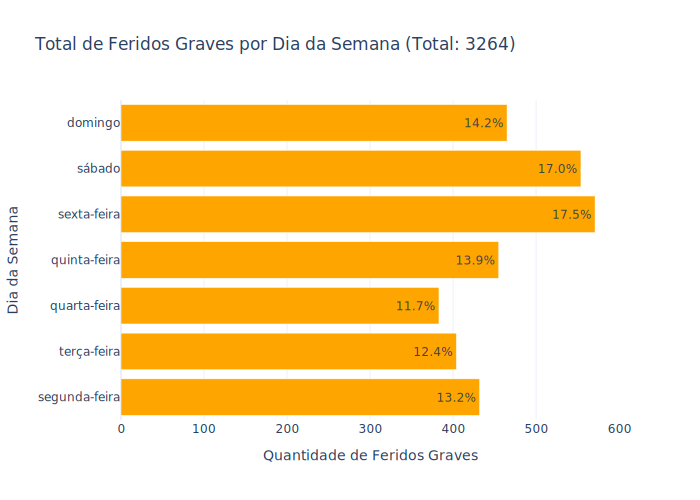

In [13]:

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "svg"

ordem_dias = ['segunda-feira', 'terça-feira', 'quarta-feira', 
              'quinta-feira', 'sexta-feira', 'sábado', 'domingo']

# organizar + calcular percentual em uma etapa só
dados['dia_semana'] = pd.Categorical(
    dados['dia_semana'].str.lower(), 
    categories=ordem_dias, 
    ordered=True
)
dados = dados.sort_values('dia_semana')
dados['percentual'] = dados['feridos'] / dados['feridos'].sum() * 100
  
# 1. Criar o resumo (Formato Longo/Agrupado)
# Isso consolida os dados por dia para o gráfico fazer sentido
resumo = dados.groupby('dia_semana', observed=True)['feridos_graves'].sum().reset_index()
total_geral = resumo['feridos_graves'].sum()
resumo['percentual'] = (resumo['feridos_graves'] / total_geral * 100).round(1)

# 2. Criar o gráfico com Plotly
fig = go.Figure(data=[go.Bar(
    y=resumo['dia_semana'],
    x=resumo['feridos_graves'],
    text=resumo['percentual'].astype(str) + '%', # Adiciona o símbolo de % no texto
    textposition='auto',
    marker_color='orange',
    orientation='h'
)])

fig.update_layout(
    title=f"Total de Feridos Graves por Dia da Semana (Total: {total_geral})",
    yaxis_title="Dia da Semana",
    xaxis_title="Quantidade de Feridos Graves",
    template="plotly_white"
)

fig.show()

O seguinte gráfico representa o percentual de feridos graves em acidentes no Brasil no período de janeiro a fevereiro de 2026. Observa-se que a maior parte dos acidentes ocorre no final de semana, principalmente no sexta-feira, onde se nota o maior percentual de casos, cerca de 17,5% do total de feridos graves. Em segundo lugar vem a sábado, seguida do domingo.


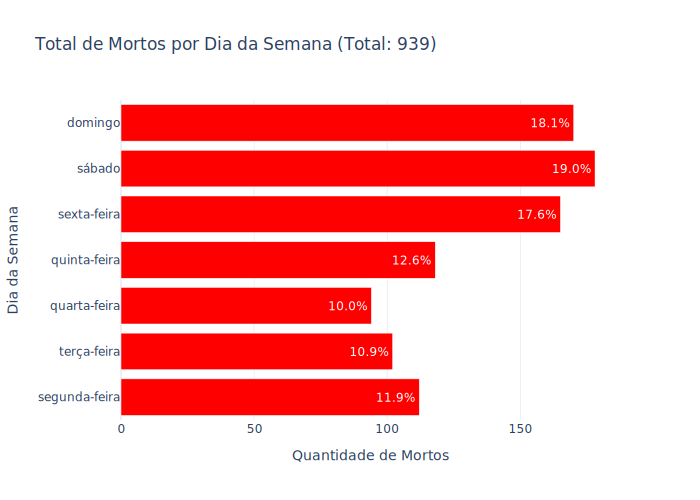

In [14]:
dados['percentual'] = dados['mortos'] / dados['mortos'].sum() * 100

# 1. Criar o resumo (Formato Longo/Agrupado)
# Isso consolida os dados por dia para o gráfico fazer sentido
resumo = dados.groupby('dia_semana', observed=True)['mortos'].sum().reset_index()
total_geral = resumo['mortos'].sum()
resumo['percentual'] = (resumo['mortos'] / total_geral * 100).round(1)

# 2. Criar o gráfico com Plotly
fig = go.Figure(data=[go.Bar(
    y=resumo['dia_semana'],
    x=resumo['mortos'],
    text=resumo['percentual'].astype(str) + '%', # Adiciona o símbolo de % no texto
    textposition='auto',
    marker_color='red',
    orientation='h'
)])

fig.update_layout(
    title=f"Total de Mortos por Dia da Semana (Total: {total_geral})",
    yaxis_title="Dia da Semana",
    xaxis_title="Quantidade de Mortos",
    template="plotly_white"
)

fig.show()

O seguinte gráfico representa o percentual de mortos em acidentes no Brasil no período de janeiro a fevereiro de 2026. Observa-se que a maior parte dos acidentes que acarretaram morte ocorre no final de semana, principalmente no sábado, onde se nota o maior percentual de casos, cerca de 19% do total de mortes. Em segundo lugar vem a sexta-feira, seguida do domingo.


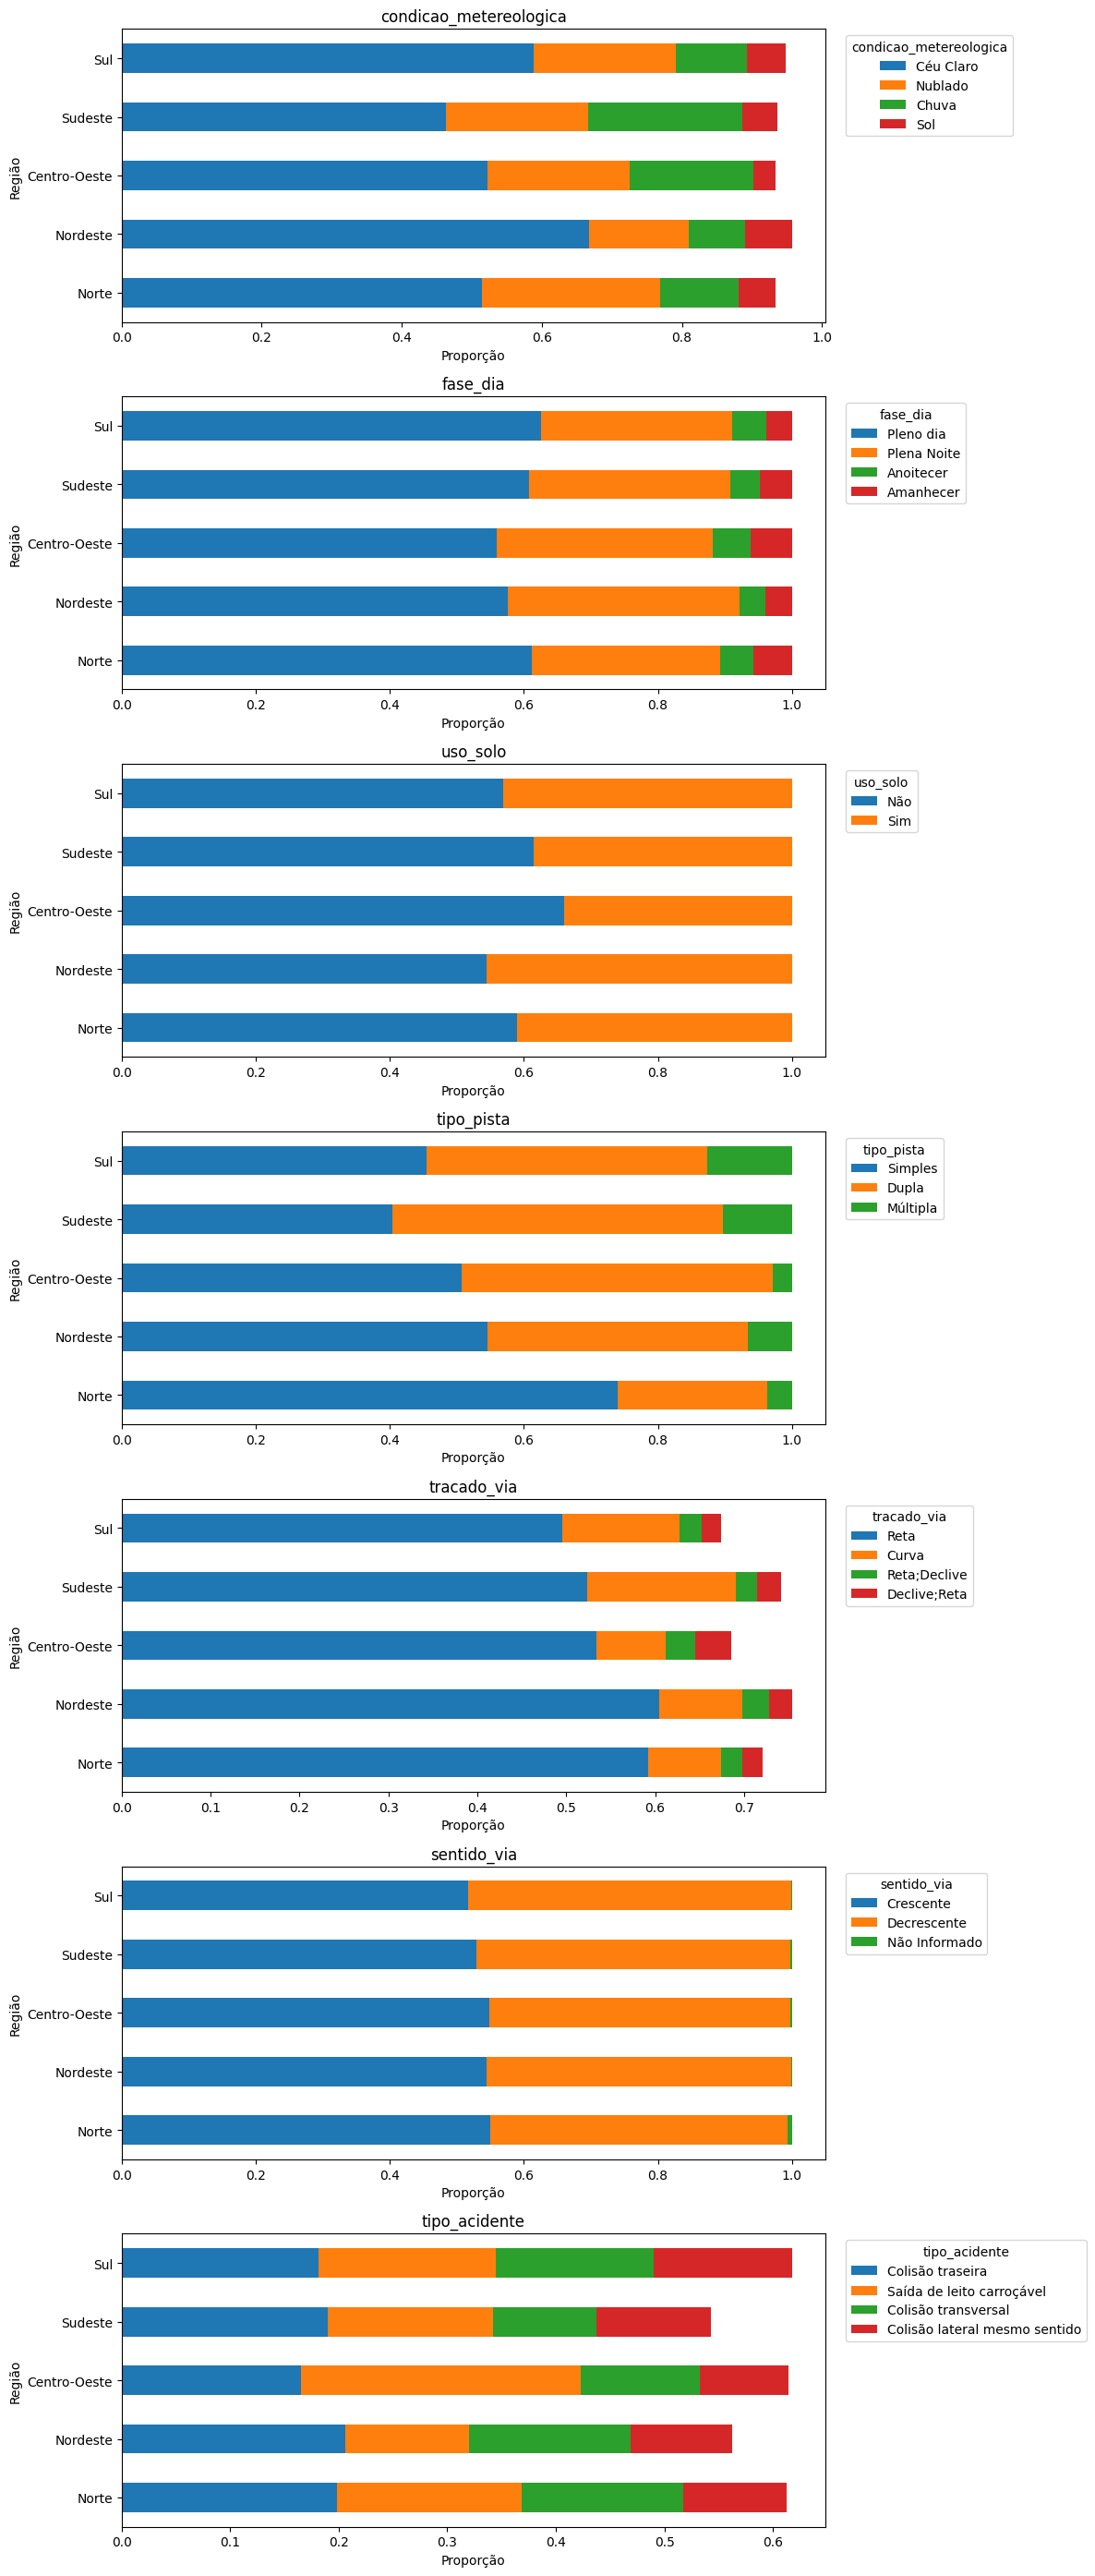

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

map_regiao = {
    "AC":"Norte","AP":"Norte","AM":"Norte","PA":"Norte","RO":"Norte","RR":"Norte","TO":"Norte",
    "AL":"Nordeste","BA":"Nordeste","CE":"Nordeste","MA":"Nordeste","PB":"Nordeste","PE":"Nordeste","PI":"Nordeste","RN":"Nordeste","SE":"Nordeste",
    "DF":"Centro-Oeste","GO":"Centro-Oeste","MT":"Centro-Oeste","MS":"Centro-Oeste",
    "ES":"Sudeste","MG":"Sudeste","RJ":"Sudeste","SP":"Sudeste",
    "PR":"Sul","RS":"Sul","SC":"Sul"
}

dados["regiao"] = dados["uf"].map(map_regiao)

col_names = [
    "condicao_metereologica", "fase_dia", "uso_solo",
    "tipo_pista", "tracado_via", "sentido_via", "tipo_acidente"
]

ordem = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

fig, axes = plt.subplots(len(col_names), 1, figsize=(12, 4 * len(col_names)))

if len(col_names) == 1:
    axes = [axes]

for i, col in enumerate(col_names):
    tab = pd.crosstab(
        dados["regiao"],
        dados[col],
        normalize="index"
    )

    top_cat = dados[col].value_counts().nlargest(4).index
    tab = tab[top_cat]
    tab = tab.reindex(ordem)

    tab.plot(
        kind="barh",
        stacked=True,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Proporção")
    axes[i].set_ylabel("Região")
    axes[i].legend(
        title=col,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

plt.tight_layout()
plt.show()

A figura apresenta a distribuição proporcional das categorias das variáveis por macrorregião do Brasil, ou seja, mostra como os acidentes se distribuem internamente em cada região, independentemente do volume total.

De modo geral, as condições meteorológicas e a fase do dia apresentam padrões semelhantes entre as regiões, com predominância de céu claro e ocorrências durante o período diurno, indicando que esses fatores não diferenciam significativamente o perfil regional dos acidentes.

O uso do solo evidencia que a maior parte dos acidentes ocorre fora de áreas urbanas, reforçando o caráter rodoviário dos dados analisados.

As principais diferenças regionais aparecem na variável tipo de pista. Norte e Centro-Oeste concentram maior proporção de acidentes em pistas simples, enquanto Sudeste e Sul apresentam maior participação de pistas duplas, refletindo diferenças na infraestrutura viária.

Quanto ao tipo de acidente, observa-se que Norte e Nordeste apresentam maior participação de eventos associados à perda de controle ou maior vulnerabilidade, enquanto Sudeste e Sul concentram mais colisões traseiras, padrão típico de regiões com maior fluxo de veículos.

Em síntese, os resultados indicam que o perfil dos acidentes varia entre as regiões e está mais associado às condições estruturais das rodovias e ao padrão de tráfego do que a fatores ambientais.
